In [2]:
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter('ignore')

In [3]:
df = pd.read_csv("ETTh1.csv")
df["date"] = pd.to_datetime(df["date"])

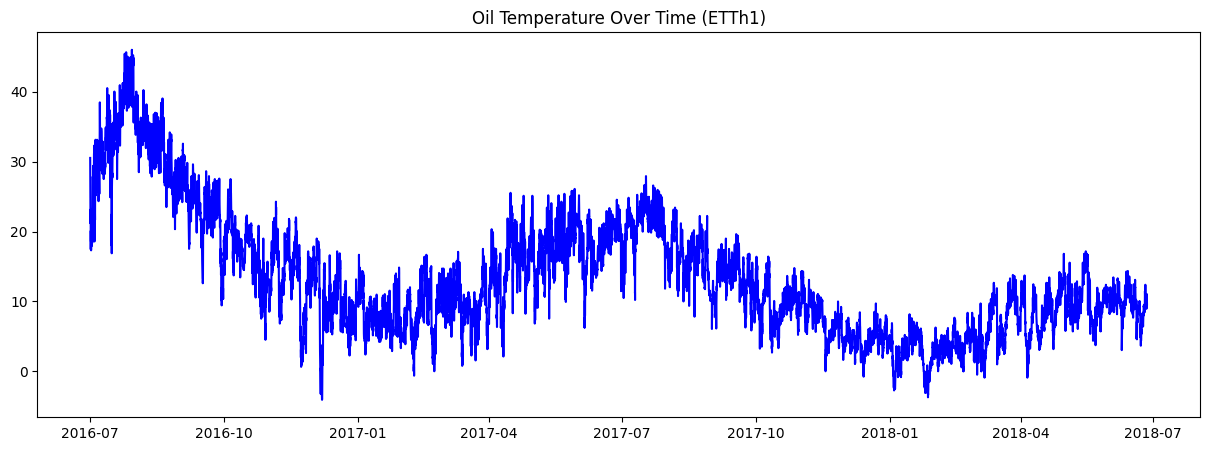

In [4]:
plt.figure(figsize=(15, 5))
plt.plot(df["date"], df["OT"], label="Oil Temperature (OT)", color="blue")
plt.title("Oil Temperature Over Time (ETTh1)")
plt.show()

In [5]:
from sklearn.preprocessing import MinMaxScaler

In [6]:
data_to_scale = df[["OT"]]

In [7]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_to_scale)

In [8]:
print("▼ スケーリング前の油温（元の数字）")
print(data_to_scale.head())

▼ スケーリング前の油温（元の数字）
          OT
0  30.531000
1  27.787001
2  27.787001
3  25.044001
4  21.948000


In [9]:
print("\n▼ スケーリング後の油温（0〜1に押しつぶされた数字）")
print(scaled_data[:5])


▼ スケーリング後の油温（0〜1に押しつぶされた数字）
[[0.69101763]
 [0.63623297]
 [0.63623297]
 [0.58146826]
 [0.5196558 ]]


In [10]:
import numpy as np

In [11]:
X = []
y = []

In [12]:
time_steps = 24

In [13]:
for i in range(len(scaled_data) - time_steps):
    X.append(scaled_data[i : i + time_steps]) 
    y.append(scaled_data[i + time_steps])

In [14]:
X = np.array(X)
y = np.array(y)

In [15]:
print("▼ 問題集の数と形")
print(f"問題(X)の形: {X.shape}") 
print(f"答え(y)の形: {y.shape}")

▼ 問題集の数と形
問題(X)の形: (17396, 24, 1)
答え(y)の形: (17396, 1)


In [16]:
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

In [17]:
X_train = X[:split_index] 
y_train = y[:split_index]

In [18]:
X_test = X[split_index:]   
y_test = y[split_index:] 

In [19]:
print("▼ ドリルの分割結果")
print(f"ひたすら特訓する勉強用データ (X_train): {len(X_train)}問")
print(f"実力を試す本番テスト用データ (X_test):  {len(X_test)}問")

▼ ドリルの分割結果
ひたすら特訓する勉強用データ (X_train): 13916問
実力を試す本番テスト用データ (X_test):  3480問


In [20]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)

X_train_flat = X_train.reshape(X_train.shape[0], X_train.shape[1])
X_test_flat = X_test.reshape(X_test.shape[0], X_test.shape[1])
y_train_flat = y_train.ravel()  

print("モデルの学習を開始します")

model.fit(X_train_flat, y_train_flat)

print("学習が完了しました")

モデルの学習を開始します
学習が完了しました


テスト問題を解いています


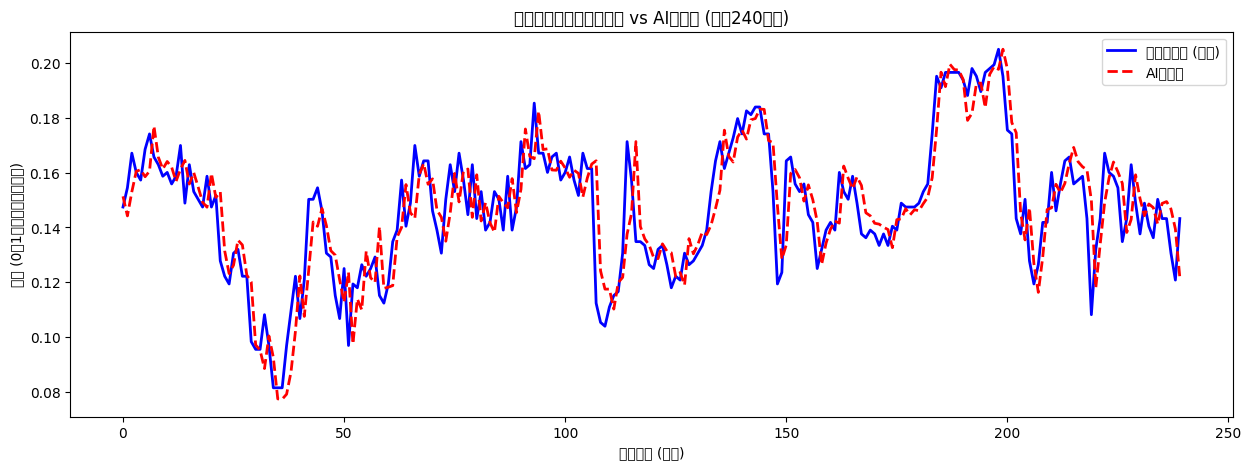

グラフの出力が完了しました！


In [21]:
import matplotlib.pyplot as plt

print("テスト問題を解いています")
predictions = model.predict(X_test_flat)
y_test_flat = y_test.ravel()

plt.figure(figsize=(15, 5))

plt.plot(y_test_flat[:240], label="実際の油温 (現実)", color="blue", linewidth=2)
plt.plot(predictions[:240], label="AIの予測", color="red", linestyle="--", linewidth=2)

plt.title("答え合わせ：現実の油温 vs AIの予測 (直近240時間)")
plt.xlabel("時間経過 (時間)")
plt.ylabel("油温 (0〜1にスケーリング済)")
plt.legend()
plt.show()

print("グラフの出力が完了しました！")

Testing model


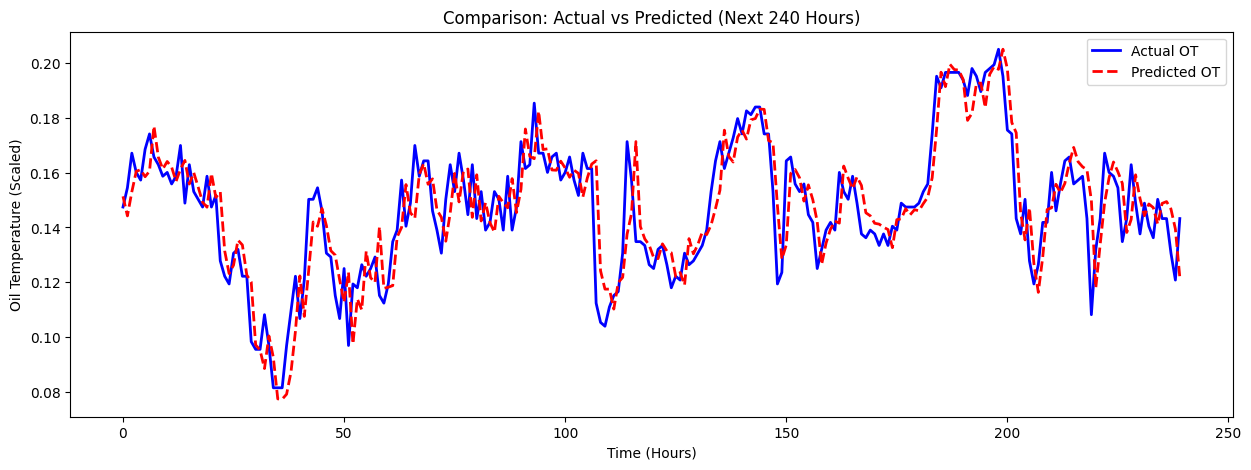

Graph output completed!


In [22]:
import matplotlib.pyplot as plt

print("Testing model")
predictions = model.predict(X_test_flat)
y_test_flat = y_test.ravel()

plt.figure(figsize=(15, 5))

plt.plot(y_test_flat[:240], label="Actual OT", color="blue", linewidth=2)
plt.plot(predictions[:240], label="Predicted OT", color="red", linestyle="--", linewidth=2)

plt.title("Comparison: Actual vs Predicted (Next 240 Hours)")
plt.xlabel("Time (Hours)")
plt.ylabel("Oil Temperature (Scaled)")
plt.legend()
plt.show()

print("Graph output completed!")

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(y_test_flat, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_flat, predictions)

print("Model Evaluation Metrics:")
print(f"MSE  : {mse:.5f}")
print(f"RMSE : {rmse:.5f}")
print(f"MAE  : {mae:.5f}")

Model Evaluation Metrics:
MSE  : 0.00018
RMSE : 0.01333
MAE  : 0.00929


In [24]:
predictions_original = scaler.inverse_transform(predictions.reshape(-1, 1))
y_test_original = scaler.inverse_transform(y_test_flat.reshape(-1, 1))

rmse_original = np.sqrt(mean_squared_error(y_test_original, predictions_original))
mae_original = mean_absolute_error(y_test_original, predictions_original)

print("▼ Real-world Temperature Evaluation:")
print(f"RMSE : {rmse_original:.2f} °C")
print(f"MAE  : {mae_original:.2f} °C")

▼ Real-world Temperature Evaluation:
RMSE : 0.67 °C
MAE  : 0.47 °C
